Identifying the version of Keras.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [35]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [ ]:
import os

print(os.listdir(dataset_path))

Manual Gradient Calculation in Numpy.

In [ ]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
  return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
  return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
  x -= learning_rate * gradient(x)
  print(f"x: {x}, f(x): {f(x)}")

Gradient Computations with Keras.

In [ ]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
  y = x ** 2 # y = x^2
grad = tape.gradient(y, x) # Computes dy/dx automatically
print(grad.numpy()) # Output: 10.0

Example: Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).

In [ ]:
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

Implementation of Activation Function with Keras.

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid")

Manually Training Network in Numpy.

In [ ]:
import numpy as np

# Sample data initialization
x_train = np.array([[1.0], [2.0], [3.0], [4.0]])
y_train = np.array([[2.0], [4.0], [6.0], [8.0]])
weights = np.array([[0.0]])
learning_rate = 0.01

for epoch in range(10):
    # Forward pass
    y_pred = np.dot(x_train, weights)
    # Compute loss
    loss = np.mean((y_pred - y_train) ** 2)
    # Compute gradients manually
    gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)
    # Update weights
    weights -= learning_rate * gradients
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Weights: {weights[0][0]:.4f}")


In [ ]:
import tensorflow as tf

# Define a simple Sequential model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)), # Recommended way to specify input shape
    tf.keras.layers.Dense(units=1)
])

# Compile the model
model.compile(optimizer='sgd', loss='mean_squared_error')

# Now you can fit the model
model.fit(x_train, y_train, epochs=10, batch_size=32)

In [ ]:
model.fit(x_train, y_train, epochs=10, batch_size=32)

Layers in Keras.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
Dense(64, activation='relu', input_shape=(784,)),
Dense(10, activation='softmax')
])

Implementing SGD in Numpy.

In [ ]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
  gradient = np.random.randn(3, 3) # Fake gradient for illustration
  weights -= learning_rate * gradient

In Keras.

In [ ]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

Task 1: Data Preparation

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
for root, dirs, files in os.walk("devnagari_digit_extracted"):
    print(root)

In [26]:
def load_data(data_dir):
    images=[]
    labels=[]

    for label in os.listdir(data_dir):
        label_path=os.path.join(data_dir, label)

        if not os.path.isdir(label_path):
            continue

        digit=int(label.split('_')[1])

        for file in os.listdir(label_path):
            img_path=os.path.join(label_path, file)
            try:
                img=Image.open(img_path).convert('L')
                img=img.resize((28, 28))
                img=np.array(img)/255.0
                images.append(img)
                labels.append(digit)
            except:
                pass
    return np.array(images), np.array(labels)

base_path = "/content/drive/MyDrive/AI and Machine learning/DevanagariHandwrittenDigitDataset"
X_train, y_train = load_data(os.path.join(base_path, "Train"))
X_test, y_test = load_data(os.path.join(base_path, "Test"))

Training set:(17000, 28, 28),Labels: (17000, 10)
Test set:(3000, 28, 28),Labels: (3000, 10)


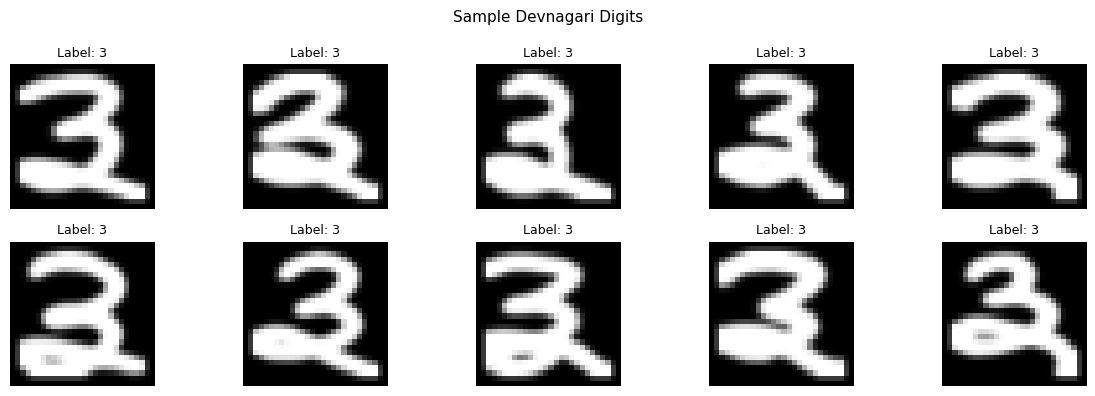

In [27]:
X_train=X_train.reshape(-1, 28, 28)
X_test=X_test.reshape(-1, 28, 28)

y_train=to_categorical(y_train, 10)
y_test=to_categorical(y_test, 10)

print(f"Training set:{X_train.shape},Labels: {y_train.shape}")
print(f"Test set:{X_test.shape},Labels: {y_test.shape}")

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}", fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Devnagari Digits", fontsize=11)
plt.tight_layout()
plt.show()

Task 2: Build the FCN Model
Model Architecture
• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

1st hidden layer: 64 neurons

2nd hidden layer: 128 neurons

3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a softmax activation function.

In [28]:
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(256, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [29]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [30]:
checkpoint=ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss')
early_stop=EarlyStopping(patience=5, restore_best_weights=True)

history=model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2973 - loss: 1.9612

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5065 - loss: 1.5630 - val_accuracy: 0.0000e+00 - val_loss: 7.6421
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8464 - loss: 0.4932 - val_accuracy: 0.0000e+00 - val_loss: 8.8667
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9304 - loss: 0.2529 - val_accuracy: 0.0000e+00 - val_loss: 9.5929
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9513 - loss: 0.1702 - val_accuracy: 0.0000e+00 - val_loss: 9.9718
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9636 - loss: 0.1277 - val_accuracy: 0.0000e+00 - val_loss: 10.2561
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9704 - loss: 0.1023 - val_accuracy: 0.0000e+00 - val_loss: 10.4220


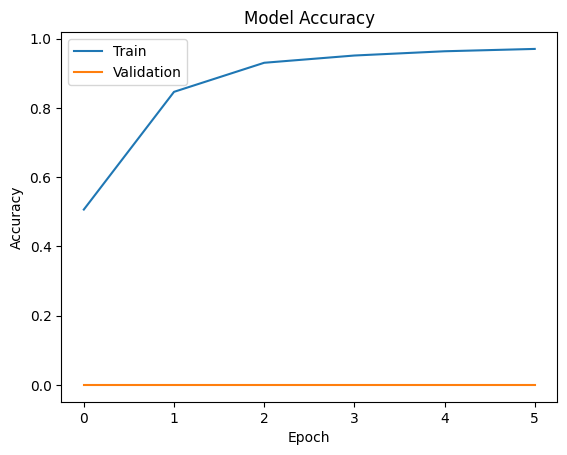

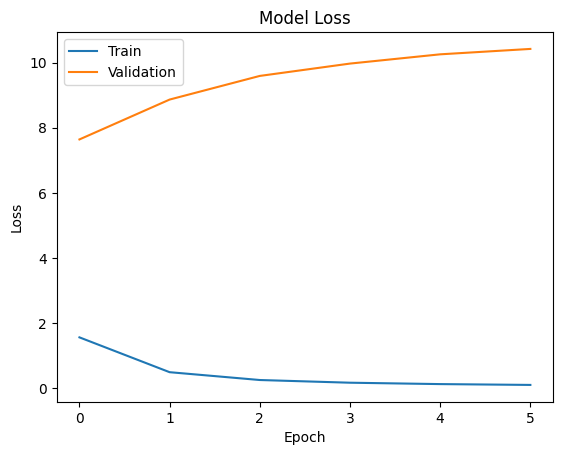

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [32]:
loss,accuracy=model.evaluate(X_test,y_test)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6147 - loss: 2.1548
Test Accuracy: 0.6146666407585144
Test Loss: 2.1547529697418213


Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [33]:
model.save("devnagari_fcn.h5")

loaded_model=load_model("devnagari_fcn.h5")

loss, accuracy=loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6147 - loss: 2.1548
Loaded Model Accuracy: 0.6146666407585144


Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


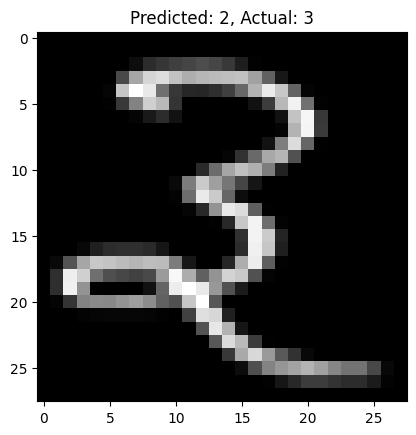

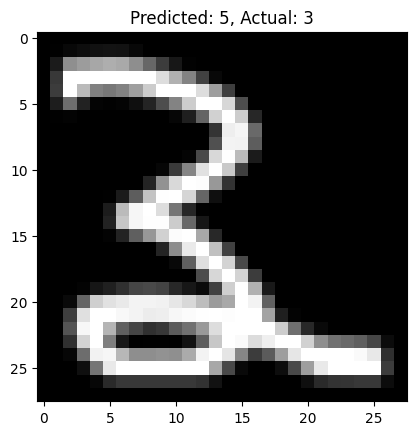

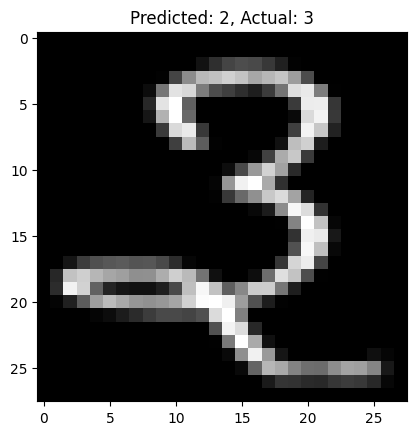

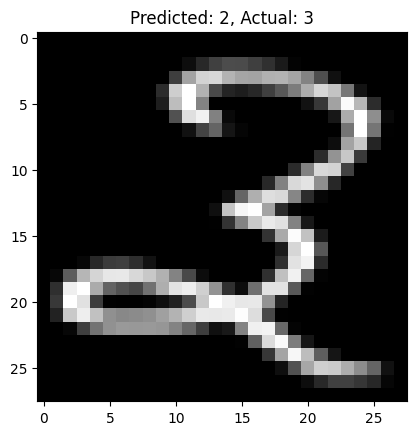

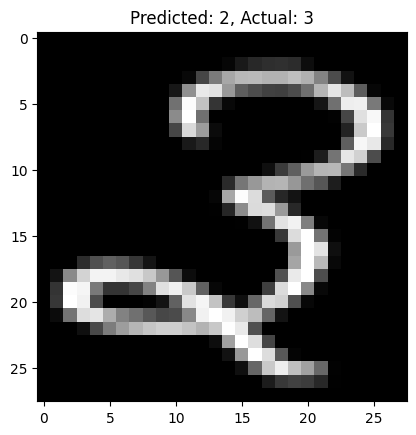

In [34]:
predictions=loaded_model.predict(X_test)
predicted_labels=np.argmax(predictions, axis=1)
true_labels=np.argmax(y_test, axis=1)

for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}, Actual: {true_labels[i]}")
    plt.show()